<a href="https://colab.research.google.com/github/BhagyashreeMohalkar/3D_RNA_Structure_prediction/blob/main/04_baseline_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# RNA3D-Predict — Baseline Model

This notebook establishes the first machine-learning baseline for coarse-grained RNA 3D structure prediction.

## Objective

The goal is to predict the 3D C4′ coordinates of an RNA from its sequence without using graph message passing or explicit geometric layers.

The baseline provides a reference point for the later E(3)-equivariant model.

## Input

For each RNA:

- nucleotide identity
- sequence position

The nucleotide identity is represented using one-hot encoding:

- A → `[1, 0, 0, 0]`
- U → `[0, 1, 0, 0]`
- G → `[0, 0, 1, 0]`
- C → `[0, 0, 0, 1]`

## Target

For every nucleotide, predict its normalized C4′ 3D coordinate:

\[
(x, y, z)
\]

The experimental coordinates are transformed into a consistent coordinate frame before training.

## Experimental Question

How much 3D structural information can be learned from RNA sequence alone before introducing explicit graph and geometric reasoning?

The resulting baseline will later be compared against the E(3)-equivariant model.

In [3]:
# ---------------------------------------------------------
# CELL 1 — Setup environment and load processed graphs
# ---------------------------------------------------------
# Purpose:
#   Mount Google Drive, install the PyTorch Geometric
#   dependency required to deserialize our saved graph
#   objects, and load the V1 train/validation/test datasets.
#
# The saved .pt files contain PyG Data objects, so
# torch_geometric must be available before torch.load() runs.
# ---------------------------------------------------------

from google.colab import drive
from pathlib import Path

# ---------------------------------------------------------
# Install PyTorch Geometric
# ---------------------------------------------------------
# Colab already provides PyTorch in the standard runtime.
# We only need to install PyTorch Geometric for this project.
# ---------------------------------------------------------

!pip -q install torch-geometric


# ---------------------------------------------------------
# Import required libraries
# ---------------------------------------------------------

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Import PyTorch Geometric.
import torch_geometric

print("PyTorch version:",
      torch.__version__)

print(
    "PyTorch Geometric version:",
    torch_geometric.__version__
)


# ---------------------------------------------------------
# Mount Google Drive
# ---------------------------------------------------------

drive.mount("/content/drive")


# ---------------------------------------------------------
# Define project paths
# ---------------------------------------------------------

PROJECT_DIR = Path(
    "/content/drive/MyDrive/RNA 3D Structure Prediction"
)

PROCESSED_DIR = (
    PROJECT_DIR
    / "Dataset"
    / "processed"
)


# ---------------------------------------------------------
# Define processed dataset paths
# ---------------------------------------------------------

TRAIN_GRAPH_PATH = (
    PROCESSED_DIR / "train_v1.pt"
)

VALIDATION_GRAPH_PATH = (
    PROCESSED_DIR / "validation_v1.pt"
)

TEST_GRAPH_PATH = (
    PROCESSED_DIR / "test_v1.pt"
)


# ---------------------------------------------------------
# Verify that all processed datasets exist
# ---------------------------------------------------------

assert TRAIN_GRAPH_PATH.exists(), (
    f"Training graph file not found:\n{TRAIN_GRAPH_PATH}"
)

assert VALIDATION_GRAPH_PATH.exists(), (
    f"Validation graph file not found:\n{VALIDATION_GRAPH_PATH}"
)

assert TEST_GRAPH_PATH.exists(), (
    f"Test graph file not found:\n{TEST_GRAPH_PATH}"
)


# ---------------------------------------------------------
# Load the saved PyG graph datasets
# ---------------------------------------------------------

train_graphs = torch.load(
    TRAIN_GRAPH_PATH,
    weights_only=False
)

validation_graphs = torch.load(
    VALIDATION_GRAPH_PATH,
    weights_only=False
)

test_graphs = torch.load(
    TEST_GRAPH_PATH,
    weights_only=False
)


# ---------------------------------------------------------
# Basic validation
# ---------------------------------------------------------

print("\nLoaded graph datasets:")

print("Train graphs:",
      len(train_graphs))

print("Validation graphs:",
      len(validation_graphs))

print("Test graphs:",
      len(test_graphs))


assert len(train_graphs) == 426
assert len(validation_graphs) == 55
assert len(test_graphs) == 55

print("\nProcessed dataset loading: PASSED")

PyTorch version: 2.11.0+cu128
PyTorch Geometric version: 2.8.0.post1
Mounted at /content/drive

Loaded graph datasets:
Train graphs: 426
Validation graphs: 55
Test graphs: 55

Processed dataset loading: PASSED


In [4]:
# ---------------------------------------------------------
# GPU AVAILABILITY CHECK
# ---------------------------------------------------------
# Purpose:
#   Check whether the current Google Colab runtime has
#   access to an NVIDIA GPU.
#
# We will use the GPU later for neural-network training.
# ---------------------------------------------------------

import torch

# Check whether CUDA is available.
gpu_available = torch.cuda.is_available()

print("CUDA available:", gpu_available)

if gpu_available:

    # Display the GPU name.
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

    # Display the CUDA version recognized by PyTorch.
    print(
        "CUDA version:",
        torch.version.cuda
    )

else:

    print(
        "No GPU detected. "
        "Training will currently use CPU."
    )

CUDA available: True
GPU: Tesla T4
CUDA version: 12.8


In [5]:
# ---------------------------------------------------------
# CELL 2 — Inspect experimental coordinate distributions
# ---------------------------------------------------------
# Purpose:
#   Examine the raw C4' coordinate values across the training
#   structures before deciding how to normalize the targets.
#
# Why:
#   PDB coordinates are defined in arbitrary global coordinate
#   frames. Different RNAs can be translated and rotated relative
#   to one another even when their internal geometry is valid.
#
# We first measure this rather than assuming a normalization
# strategy.
# ---------------------------------------------------------

# Collect all C4' coordinates from the training set.
all_train_coordinates = torch.cat(
    [
        graph.y
        for graph in train_graphs
    ],
    dim=0
).numpy()

print(
    "Total nucleotide coordinates:",
    len(all_train_coordinates)
)

# ---------------------------------------------------------
# Coordinate-value statistics
# ---------------------------------------------------------

coordinate_df = pd.DataFrame(
    all_train_coordinates,
    columns=["x", "y", "z"]
)

print("\nCoordinate statistics:")
display(
    coordinate_df.describe()
)


# ---------------------------------------------------------
# Calculate the centroid of every RNA structure.
# ---------------------------------------------------------
# The centroid gives us an idea of how much the global
# coordinate origin varies from structure to structure.
# ---------------------------------------------------------

centers = []

for graph in train_graphs:

    coordinates = graph.y.numpy()

    center = coordinates.mean(
        axis=0
    )

    centers.append(center)

centers = np.array(centers)

print("\nMean structure centroid:")
print(
    centers.mean(axis=0)
)

print("\nStandard deviation of structure centroids:")
print(
    centers.std(axis=0)
)

print("\nMinimum centroid value:")
print(
    centers.min(axis=0)
)

print("\nMaximum centroid value:")
print(
    centers.max(axis=0)
)

Total nucleotide coordinates: 23281

Coordinate statistics:


,x,y,z
count,23281.000000,23281.000000,23281.000000
mean,23.485600,30.332420,32.169918
std,59.884441,73.574615,69.355568
min,-333.584015,-294.231995,-319.989990
25%,-7.075000,-6.160000,-5.526000
50%,9.109000,9.627000,11.377000
75%,36.988998,38.258999,46.862000
max,458.148987,891.036011,428.088989



Mean structure centroid:
[14.291598 18.406399 18.729324]

Standard deviation of structure centroids:
[50.83133  67.26909  59.512608]

Minimum centroid value:
[-314.17188 -277.54608 -303.46423]

Maximum centroid value:
[448.18842 871.37683 392.45026]


In [6]:
# ---------------------------------------------------------
# CELL 3 — Inspect coordinate centering on one RNA
# ---------------------------------------------------------
# Purpose:
#   Demonstrate the effect of translating one RNA structure
#   so that its centroid is at the origin.
#
# Centering removes translation, but does not remove rotation.
# We will use this experiment to decide whether additional
# normalization is necessary.
# ---------------------------------------------------------

# Select one training RNA.
example_graph = train_graphs[0]

# Convert target coordinates to NumPy.
coords = example_graph.y.numpy()

# Calculate the centroid.
centroid = coords.mean(
    axis=0
)

# Center the structure at the origin.
centered_coords = (
    coords - centroid
)

print("PDB ID:", example_graph.pdb_id)
print("Number of nucleotides:", len(coords))

print("\nOriginal first 5 coordinates:")
print(coords[:5])

print("\nCentroid:")
print(centroid)

print("\nCentered first 5 coordinates:")
print(centered_coords[:5])

print(
    "\nCentered centroid:",
    centered_coords.mean(axis=0)
)

PDB ID: 6WLQ
Number of nucleotides: 118

Original first 5 coordinates:
[[ 71.595  91.574  92.125]
 [ 75.136  96.304  88.6  ]
 [ 78.166  97.412  83.342]
 [ 79.438  97.529  77.154]
 [ 82.42  101.164  78.12 ]]

Centroid:
[89.450935 89.26257  87.67146 ]

Centered first 5 coordinates:
[[-17.855934     2.3114243    4.453537  ]
 [-14.314934     7.0414276    0.92853546]
 [-11.284935     8.149429    -4.32946   ]
 [-10.012932     8.266426   -10.517464  ]
 [ -7.030937    11.901428    -9.55146   ]]

Centered centroid: [-3.2974501e-06  1.0862189e-05  4.5905681e-06]


In [7]:
# ---------------------------------------------------------
# CELL 4 — Center the experimental C4' coordinates
# ---------------------------------------------------------
# Purpose:
#   Remove arbitrary translation from every RNA structure by
#   subtracting its own coordinate centroid.
#
# The original experimental coordinates stored in graph.y
# are NOT modified.
#
# A new attribute is created:
#     graph.y_centered
#
# This will be the V1 baseline target.
# ---------------------------------------------------------

def center_coordinates(graph):
    """
    Center one RNA structure at its coordinate centroid.

    Parameters
    ----------
    graph : torch_geometric.data.Data
        RNA graph containing experimental C4' coordinates
        in graph.y.

    Returns
    -------
    torch.Tensor
        Centered C4' coordinates with shape (N, 3).
    """

    # Extract the experimental coordinates.
    coordinates = graph.y

    # Calculate the centroid across all nucleotides.
    centroid = coordinates.mean(
        dim=0,
        keepdim=True
    )

    # Remove the centroid from every coordinate.
    centered = (
        coordinates - centroid
    )

    return centered


# ---------------------------------------------------------
# Apply the transformation to all three splits.
# ---------------------------------------------------------

for graph in train_graphs:

    graph.y_centered = center_coordinates(
        graph
    )

for graph in validation_graphs:

    graph.y_centered = center_coordinates(
        graph
    )

for graph in test_graphs:

    graph.y_centered = center_coordinates(
        graph
    )


print("Centered coordinates created successfully.")

Centered coordinates created successfully.


In [9]:
# ---------------------------------------------------------
# CELL 5 — Validate centered coordinate targets
# ---------------------------------------------------------
# Purpose:
#   Confirm that the centroid of every RNA's centered target
#   is approximately zero.
#
# Because the coordinates are stored using floating-point
# values, a tiny numerical residual is expected after
# subtraction. A tolerance of 1e-4 is sufficient here.
# ---------------------------------------------------------

def validate_centering(graphs, split_name):
    """
    Validate that centered coordinates have approximately
    zero centroid for every RNA in a dataset split.
    """

    maximum_centroid_error = 0.0

    for graph in graphs:

        # Calculate the centroid after centering.
        centroid = graph.y_centered.mean(
            dim=0
        )

        # Measure the largest absolute residual.
        error = torch.abs(
            centroid
        ).max().item()

        maximum_centroid_error = max(
            maximum_centroid_error,
            error
        )

    print(
        f"{split_name}: "
        f"maximum centroid error = "
        f"{maximum_centroid_error:.8f}"
    )

    # Allow a very small floating-point residual.
    assert maximum_centroid_error < 1e-4, (
        f"{split_name}: centering error is too large."
    )


# ---------------------------------------------------------
# Validate all three splits.
# ---------------------------------------------------------

validate_centering(
    train_graphs,
    "Train"
)

validate_centering(
    validation_graphs,
    "Validation"
)

validate_centering(
    test_graphs,
    "Test"
)

print(
    "\nCoordinate-centering validation: PASSED"
)

Train: maximum centroid error = 0.00003342
Validation: maximum centroid error = 0.00002531
Test: maximum centroid error = 0.00001831

Coordinate-centering validation: PASSED


In [10]:
# ---------------------------------------------------------
# CELL 6 — Compare raw and centered coordinate ranges
# ---------------------------------------------------------
# Purpose:
#   Quantify how much global translation contributed to the
#   large coordinate variation we observed in the raw PDB data.
# ---------------------------------------------------------

raw_coordinates = torch.cat(
    [
        graph.y
        for graph in train_graphs
    ],
    dim=0
)

centered_coordinates = torch.cat(
    [
        graph.y_centered
        for graph in train_graphs
    ],
    dim=0
)

raw_df = pd.DataFrame(
    raw_coordinates.numpy(),
    columns=["x", "y", "z"]
)

centered_df = pd.DataFrame(
    centered_coordinates.numpy(),
    columns=["x", "y", "z"]
)

print("=== RAW COORDINATES ===")
display(
    raw_df.describe()
)

print("\n=== CENTERED COORDINATES ===")
display(
    centered_df.describe()
)

=== RAW COORDINATES ===


,x,y,z
count,23281.000000,23281.000000,23281.000000
mean,23.485600,30.332420,32.169918
std,59.884441,73.574615,69.355568
min,-333.584015,-294.231995,-319.989990
25%,-7.075000,-6.160000,-5.526000
50%,9.109000,9.627000,11.377000
75%,36.988998,38.258999,46.862000
max,458.148987,891.036011,428.088989



=== CENTERED COORDINATES ===


,x,y,z
count,2.328100e+04,2.328100e+04,2.328100e+04
mean,2.323457e-07,-1.127319e-07,3.989858e-08
std,1.326677e+01,1.431121e+01,1.513474e+01
min,-5.816977e+01,-6.971688e+01,-7.295378e+01
25%,-8.350939e+00,-8.691339e+00,-8.601723e+00
50%,-5.084324e-02,1.334524e-02,-1.409912e-02
75%,8.248612e+00,8.764725e+00,8.716843e+00
max,5.566830e+01,6.373394e+01,8.489978e+01


In [11]:
# ---------------------------------------------------------
# CELL 7 — Build baseline sequence features
# ---------------------------------------------------------
# Purpose:
#   Create the input features for the sequence-only baseline.
#
# Each nucleotide receives:
#
#   1. One-hot nucleotide identity:
#        A, U, G, C  -> 4 features
#
#   2. Normalized sequence position:
#        position / (N - 1) -> 1 feature
#
# Total input features per nucleotide:
#        5
#
# The baseline does NOT receive:
#   - experimental coordinates
#   - distance information
#   - graph edges
#   - structural features
# ---------------------------------------------------------

def create_baseline_features(graph):
    """
    Create sequence-only features for one RNA graph.

    Returns
    -------
    torch.Tensor
        Shape: (N, 5)
    """

    # Use the existing one-hot nucleotide features.
    nucleotide_features = graph.x

    num_nodes = nucleotide_features.size(0)

    # -----------------------------------------------------
    # Create normalized sequence positions.
    # -----------------------------------------------------
    # Example for N = 5:
    #     [0.00, 0.25, 0.50, 0.75, 1.00]
    # -----------------------------------------------------

    if num_nodes == 1:
        positions = torch.zeros(
            (1, 1),
            dtype=torch.float32
        )

    else:
        positions = torch.arange(
            num_nodes,
            dtype=torch.float32
        ).unsqueeze(1)

        positions = (
            positions / (num_nodes - 1)
        )

    # -----------------------------------------------------
    # Combine nucleotide identity + position.
    # -----------------------------------------------------

    baseline_features = torch.cat(
        [
            nucleotide_features,
            positions
        ],
        dim=1
    )

    return baseline_features


# ---------------------------------------------------------
# Test on one RNA.
# ---------------------------------------------------------

example_features = create_baseline_features(
    train_graphs[0]
)

print(
    "Baseline feature shape:",
    example_features.shape
)

print("\nFirst 5 feature vectors:")
print(
    example_features[:5]
)


# ---------------------------------------------------------
# Validate the expected dimensions.
# ---------------------------------------------------------

assert example_features.shape == (
    train_graphs[0].num_nodes,
    5
)

print("\nBaseline feature construction: PASSED")

Baseline feature shape: torch.Size([118, 5])

First 5 feature vectors:
tensor([[0.0000, 0.0000, 1.0000, 0.0000, 0.0000],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0085],
        [0.0000, 0.0000, 0.0000, 1.0000, 0.0171],
        [1.0000, 0.0000, 0.0000, 0.0000, 0.0256],
        [0.0000, 1.0000, 0.0000, 0.0000, 0.0342]])

Baseline feature construction: PASSED


In [12]:
# ---------------------------------------------------------
# CELL 8 — Define the sequence-only baseline model
# ---------------------------------------------------------
# Purpose:
#   Create a simple per-nucleotide multilayer perceptron (MLP)
#   that predicts centered C4' coordinates from sequence
#   features only.
#
# Architecture:
#
#   5 input features
#       ↓
#   Linear(5 → 64)
#       ↓
#   ReLU
#       ↓
#   Linear(64 → 64)
#       ↓
#   ReLU
#       ↓
#   Linear(64 → 3)
#
# Output:
#   Three coordinates (x, y, z) for each nucleotide.
#
# Important:
#   This baseline does NOT use:
#       - edge_index
#       - experimental coordinates as input
#       - pairwise distances
#       - structural information
# ---------------------------------------------------------

import torch.nn as nn


class SequenceBaseline(nn.Module):
    """
    Simple sequence-only baseline for RNA 3D coordinate prediction.
    """

    def __init__(
        self,
        input_dim=5,
        hidden_dim=64,
        output_dim=3
    ):
        super().__init__()

        # -------------------------------------------------
        # MLP layers
        # -------------------------------------------------

        self.network = nn.Sequential(

            # Input → first hidden representation.
            nn.Linear(
                input_dim,
                hidden_dim
            ),

            nn.ReLU(),

            # Second hidden layer.
            nn.Linear(
                hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            # Predict x, y, z.
            nn.Linear(
                hidden_dim,
                output_dim
            )
        )

    def forward(self, x):
        """
        Predict 3D coordinates for every nucleotide.

        Parameters
        ----------
        x : torch.Tensor
            Shape (N, 5)

        Returns
        -------
        torch.Tensor
            Shape (N, 3)
        """

        return self.network(x)

In [13]:
# ---------------------------------------------------------
# CELL 9 — Validate the baseline model architecture
# ---------------------------------------------------------
# Purpose:
#   Confirm that the baseline accepts our 5-dimensional
#   sequence features and produces 3D coordinates for every
#   nucleotide.
# ---------------------------------------------------------

# Select one training RNA.
example_graph = train_graphs[0]

# Create its sequence-only features.
example_features = create_baseline_features(
    example_graph
)

# Create the model.
baseline_model = SequenceBaseline()


# ---------------------------------------------------------
# Run a forward pass.
# ---------------------------------------------------------

example_prediction = baseline_model(
    example_features
)


# ---------------------------------------------------------
# Display dimensions.
# ---------------------------------------------------------

print("Input shape:",
      example_features.shape)

print(
    "Prediction shape:",
    example_prediction.shape
)


# ---------------------------------------------------------
# Validate dimensions.
# ---------------------------------------------------------

assert example_prediction.shape == (
    example_graph.num_nodes,
    3
)

print(
    "\nBaseline model architecture validation: PASSED"
)

Input shape: torch.Size([118, 5])
Prediction shape: torch.Size([118, 3])

Baseline model architecture validation: PASSED


In [14]:
# ---------------------------------------------------------
# CELL 10 — Define baseline training configuration
# ---------------------------------------------------------
# Purpose:
#   Set up:
#       - GPU/CPU device
#       - loss function
#       - optimizer
#       - training hyperparameters
#
# The model will predict centered C4' coordinates.
# ---------------------------------------------------------

import torch.optim as optim

# ---------------------------------------------------------
# Select the available computation device.
# ---------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Training device:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ---------------------------------------------------------
# Create the baseline model and move it to the device.
# ---------------------------------------------------------

baseline_model = SequenceBaseline().to(device)


# ---------------------------------------------------------
# Define the coordinate regression loss.
# ---------------------------------------------------------
# MSE is our initial baseline loss:
#
#     mean((prediction - target)^2)
#
# This gives equal treatment to the x, y, and z coordinate
# errors.
# ---------------------------------------------------------

criterion = nn.MSELoss()


# ---------------------------------------------------------
# Define the optimizer.
# ---------------------------------------------------------
# Adam is a standard starting optimizer for neural-network
# regression.
# ---------------------------------------------------------

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)


# ---------------------------------------------------------
# Training configuration.
# ---------------------------------------------------------

NUM_EPOCHS = 100

print("\nBaseline training configuration:")
print("Learning rate:", 1e-3)
print("Weight decay:", 1e-5)
print("Epochs:", NUM_EPOCHS)
print("Loss:", "MSE")

Training device: cuda
GPU: Tesla T4

Baseline training configuration:
Learning rate: 0.001
Weight decay: 1e-05
Epochs: 100
Loss: MSE


In [15]:
# ---------------------------------------------------------
# CELL 11 — Test one baseline training step
# ---------------------------------------------------------
# Purpose:
#   Verify that the model, targets, loss function, optimizer,
#   and GPU/CPU device all work together before starting the
#   full training loop.
# ---------------------------------------------------------

# Select one training graph.
example_graph = train_graphs[0]

# Build sequence-only baseline features.
x = create_baseline_features(
    example_graph
)

# Use centered experimental coordinates as the target.
target = example_graph.y_centered


# ---------------------------------------------------------
# Move tensors to the selected device.
# ---------------------------------------------------------

x = x.to(device)
target = target.to(device)


# ---------------------------------------------------------
# Put the model into training mode.
# ---------------------------------------------------------

baseline_model.train()


# ---------------------------------------------------------
# Clear previous gradients.
# ---------------------------------------------------------

optimizer.zero_grad()


# ---------------------------------------------------------
# Forward pass.
# ---------------------------------------------------------

prediction = baseline_model(
    x
)


# ---------------------------------------------------------
# Calculate the loss.
# ---------------------------------------------------------

loss = criterion(
    prediction,
    target
)


# ---------------------------------------------------------
# Backpropagation.
# ---------------------------------------------------------

loss.backward()

optimizer.step()


# ---------------------------------------------------------
# Display results.
# ---------------------------------------------------------

print("Prediction shape:",
      prediction.shape)

print("Target shape:",
      target.shape)

print(
    "Initial training-step loss:",
    loss.item()
)

print(
    "\nSingle training step: PASSED"
)

Prediction shape: torch.Size([118, 3])
Target shape: torch.Size([118, 3])
Initial training-step loss: 228.85708618164062

Single training step: PASSED


In [16]:
# ---------------------------------------------------------
# CELL 12 — Train and validate the baseline model
# ---------------------------------------------------------
# Purpose:
#   Train the sequence-only baseline across all training RNAs
#   and evaluate it on the validation set after every epoch.
#
# The model is trained using:
#   - sequence identity
#   - normalized sequence position
#
# The target is:
#   - centered experimental C4' coordinates
#
# We track:
#   - training MSE
#   - validation MSE
#
# The model state with the lowest validation loss is saved
# as the best checkpoint.
# ---------------------------------------------------------

import copy
import time


def run_epoch(
    model,
    graphs,
    optimizer=None
):
    """
    Run one complete epoch over a list of RNA graphs.

    Parameters
    ----------
    model : torch.nn.Module
        Baseline prediction model.

    graphs : list
        RNA graph objects.

    optimizer : torch.optim.Optimizer or None
        If provided, the model is trained.
        If None, the model is evaluated.

    Returns
    -------
    float
        Mean MSE across RNA structures.
    """

    # Training mode when an optimizer is provided.
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    # -----------------------------------------------------
    # Process each RNA independently.
    # -----------------------------------------------------

    for graph in graphs:

        # Create sequence-only baseline features.
        x = create_baseline_features(
            graph
        ).to(device)

        # Use centered experimental coordinates as target.
        target = graph.y_centered.to(device)

        # Clear previous gradients during training.
        if is_training:
            optimizer.zero_grad()

        # Forward pass.
        prediction = model(x)

        # Calculate coordinate MSE.
        loss = criterion(
            prediction,
            target
        )

        # Backpropagation + parameter update.
        if is_training:
            loss.backward()
            optimizer.step()

        # Accumulate the RNA-level loss.
        total_loss += loss.item()

    # Return mean loss across structures.
    return total_loss / len(graphs)


# ---------------------------------------------------------
# Reinitialize the model and optimizer.
# ---------------------------------------------------------
# This ensures training starts from scratch rather than
# continuing the single-step test from Cell 11.
# ---------------------------------------------------------

baseline_model = SequenceBaseline().to(device)

optimizer = optim.Adam(
    baseline_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)


# ---------------------------------------------------------
# Training configuration.
# ---------------------------------------------------------

NUM_EPOCHS = 100

best_validation_loss = float("inf")

best_model_state = None

train_history = []
validation_history = []


# ---------------------------------------------------------
# Train the model.
# ---------------------------------------------------------

start_time = time.time()

for epoch in range(1, NUM_EPOCHS + 1):

    # Training epoch.
    train_loss = run_epoch(
        model=baseline_model,
        graphs=train_graphs,
        optimizer=optimizer
    )

    # Validation epoch.
    with torch.no_grad():

        validation_loss = run_epoch(
            model=baseline_model,
            graphs=validation_graphs,
            optimizer=None
        )

    # Store losses for plotting later.
    train_history.append(
        train_loss
    )

    validation_history.append(
        validation_loss
    )


    # -----------------------------------------------------
    # Save the best model according to validation loss.
    # -----------------------------------------------------

    if validation_loss < best_validation_loss:

        best_validation_loss = validation_loss

        best_model_state = copy.deepcopy(
            baseline_model.state_dict()
        )


    # -----------------------------------------------------
    # Print progress.
    # -----------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"Train MSE: {train_loss:.4f} | "
            f"Validation MSE: {validation_loss:.4f}"
        )


elapsed_time = time.time() - start_time

print(
    "\nTraining complete."
)

print(
    f"Training time: {elapsed_time / 60:.2f} minutes"
)

print(
    "Best validation MSE:",
    f"{best_validation_loss:.4f}"
)

Epoch 001 | Train MSE: 146.0851 | Validation MSE: 156.1834
Epoch 010 | Train MSE: 145.5814 | Validation MSE: 157.6206
Epoch 020 | Train MSE: 145.4819 | Validation MSE: 158.1772
Epoch 030 | Train MSE: 145.4557 | Validation MSE: 158.2943
Epoch 040 | Train MSE: 145.4434 | Validation MSE: 158.3440
Epoch 050 | Train MSE: 145.4357 | Validation MSE: 158.3767
Epoch 060 | Train MSE: 145.4272 | Validation MSE: 158.3911
Epoch 070 | Train MSE: 145.4205 | Validation MSE: 158.4010
Epoch 080 | Train MSE: 145.4146 | Validation MSE: 158.4127
Epoch 090 | Train MSE: 145.4087 | Validation MSE: 158.4258
Epoch 100 | Train MSE: 145.4055 | Validation MSE: 158.4321

Training complete.
Training time: 1.18 minutes
Best validation MSE: 156.1834


In [17]:
# ---------------------------------------------------------
# CELL 13 — Restore the best validation checkpoint
# ---------------------------------------------------------
# Purpose:
#   Replace the final model parameters with the parameters
#   that achieved the lowest validation MSE during training.
# ---------------------------------------------------------

assert best_model_state is not None, (
    "No best model checkpoint was created."
)

baseline_model.load_state_dict(
    best_model_state
)

baseline_model.eval()

print(
    "Best baseline checkpoint restored successfully."
)

print(
    "Best validation MSE:",
    f"{best_validation_loss:.4f}"
)

Best baseline checkpoint restored successfully.
Best validation MSE: 156.1834


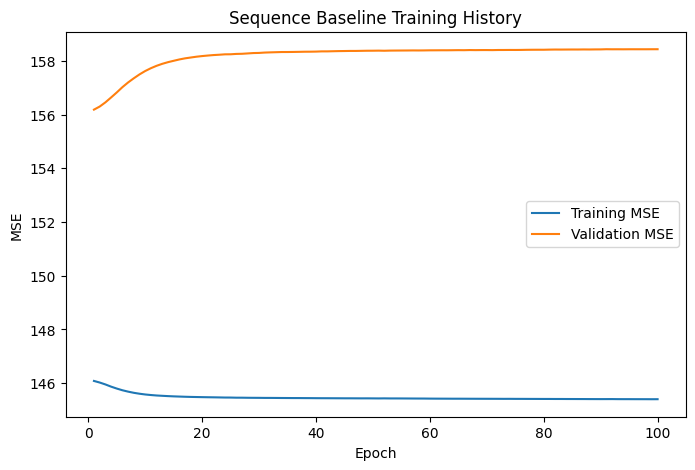

In [18]:
# ---------------------------------------------------------
# CELL 14 — Plot baseline training history
# ---------------------------------------------------------
# Purpose:
#   Visualize training and validation MSE across epochs.
#
# This helps us determine whether the baseline:
#   - learns effectively
#   - overfits
#   - underfits
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, NUM_EPOCHS + 1),
    train_history,
    label="Training MSE"
)

plt.plot(
    range(1, NUM_EPOCHS + 1),
    validation_history,
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Sequence Baseline Training History")

plt.legend()

plt.show()

In [19]:
# ---------------------------------------------------------
# CELL 15 — Evaluate the baseline on the test set
# ---------------------------------------------------------
# Purpose:
#   Evaluate the best baseline checkpoint on the unseen test
#   structures.
#
# We report:
#
#   1. Centered-coordinate MSE
#      Measures direct coordinate error.
#
#   2. Coordinate MAE
#      Measures average absolute coordinate error.
#
#   3. Kabsch-aligned RMSD
#      Removes arbitrary rotation and translation before
#      comparing the predicted and experimental structures.
#
# The Kabsch RMSD is especially important because our PDB
# structures can have different global orientations.
# ---------------------------------------------------------

import numpy as np


def kabsch_rmsd(predicted, target):
    """
    Compute RMSD after optimal rigid-body alignment.

    Parameters
    ----------
    predicted : np.ndarray
        Predicted coordinates, shape (N, 3).

    target : np.ndarray
        Experimental coordinates, shape (N, 3).

    Returns
    -------
    float
        RMSD after optimal rotation and translation.
    """

    # -----------------------------------------------------
    # Center both structures.
    # -----------------------------------------------------

    predicted_centered = (
        predicted - predicted.mean(axis=0)
    )

    target_centered = (
        target - target.mean(axis=0)
    )

    # -----------------------------------------------------
    # Compute covariance matrix.
    # -----------------------------------------------------

    covariance = (
        predicted_centered.T
        @ target_centered
    )

    # -----------------------------------------------------
    # Singular value decomposition.
    # -----------------------------------------------------

    U, _, Vt = np.linalg.svd(
        covariance
    )

    # -----------------------------------------------------
    # Correct possible reflection.
    # -----------------------------------------------------

    correction = np.eye(3)

    if np.linalg.det(
        Vt.T @ U.T
    ) < 0:

        correction[-1, -1] = -1

    # -----------------------------------------------------
    # Optimal rotation.
    # -----------------------------------------------------

    rotation = (
        Vt.T
        @ correction
        @ U.T
    )

    # -----------------------------------------------------
    # Rotate the prediction.
    # -----------------------------------------------------

    aligned_prediction = (
        predicted_centered @ rotation
    )

    # -----------------------------------------------------
    # Calculate RMSD.
    # -----------------------------------------------------

    squared_distances = (
        (aligned_prediction - target_centered) ** 2
    ).sum(axis=1)

    rmsd = np.sqrt(
        squared_distances.mean()
    )

    return float(rmsd)


# ---------------------------------------------------------
# Evaluate the best checkpoint.
# ---------------------------------------------------------

baseline_model.eval()

test_mse_values = []
test_mae_values = []
test_kabsch_rmsd_values = []

with torch.no_grad():

    for graph in test_graphs:

        # Create sequence-only input features.
        x = create_baseline_features(
            graph
        ).to(device)

        # Ground-truth centered coordinates.
        target = graph.y_centered.to(device)

        # Predict coordinates.
        prediction = baseline_model(
            x
        )

        # -------------------------------------------------
        # Direct coordinate metrics.
        # -------------------------------------------------

        mse = torch.mean(
            (prediction - target) ** 2
        ).item()

        mae = torch.mean(
            torch.abs(
                prediction - target
            )
        ).item()

        test_mse_values.append(
            mse
        )

        test_mae_values.append(
            mae
        )

        # -------------------------------------------------
        # Rotation/translation-invariant RMSD.
        # -------------------------------------------------

        rmsd = kabsch_rmsd(
            prediction.cpu().numpy(),
            target.cpu().numpy()
        )

        test_kabsch_rmsd_values.append(
            rmsd
        )


# ---------------------------------------------------------
# Aggregate test metrics.
# ---------------------------------------------------------

mean_test_mse = np.mean(
    test_mse_values
)

mean_test_mae = np.mean(
    test_mae_values
)

mean_test_kabsch_rmsd = np.mean(
    test_kabsch_rmsd_values
)


# ---------------------------------------------------------
# Display results.
# ---------------------------------------------------------

print("==============================================")
print("SEQUENCE BASELINE — TEST RESULTS")
print("==============================================")

print(
    f"Centered-coordinate MSE: "
    f"{mean_test_mse:.4f}"
)

print(
    f"Coordinate MAE: "
    f"{mean_test_mae:.4f} Å"
)

print(
    f"Kabsch-aligned RMSD: "
    f"{mean_test_kabsch_rmsd:.4f} Å"
)

SEQUENCE BASELINE — TEST RESULTS
Centered-coordinate MSE: 149.6007
Coordinate MAE: 9.2375 Å
Kabsch-aligned RMSD: 19.9726 Å


# Baseline-1 Results — Sequence MLP

The first sequence-only baseline was evaluated on the held-out V1 test set.

### Results

- **Centered-coordinate MSE:** 149.60 Å²
- **Coordinate MAE:** 9.24 Å
- **Kabsch-aligned RMSD:** 19.97 Å

The model showed limited improvement during training and reached a validation MSE of approximately 156.18 Å².

The relatively high Kabsch RMSD indicates that the model is unable to recover accurate RNA 3D geometry from independent nucleotide identity and sequence position alone.

This establishes a weak but useful sequence-only reference point.

## Interpretation

The result suggests that RNA 3D structure prediction requires information about relationships between nucleotides and their spatial arrangement, which motivates the later geometry-aware EGNN model.

In [20]:
# ---------------------------------------------------------
# CELL 16 — Define the sequence-context BiLSTM baseline
# ---------------------------------------------------------
# Purpose:
#   Build a stronger sequence-only baseline that can use
#   contextual information from neighboring and distant
#   nucleotides through a bidirectional LSTM.
#
# Input per nucleotide:
#   5 features
#       - one-hot A/U/G/C
#       - normalized sequence position
#
# Output per nucleotide:
#   3 centered C4' coordinates
#
# This model does NOT use:
#   - edge_index
#   - experimental coordinates as input
#   - pairwise distances
#   - graph message passing
# ---------------------------------------------------------

class SequenceBiLSTM(nn.Module):
    """
    Bidirectional LSTM sequence baseline for RNA 3D
    coordinate prediction.
    """

    def __init__(
        self,
        input_dim=5,
        hidden_dim=64,
        num_layers=2,
        output_dim=3,
        dropout=0.1
    ):
        super().__init__()

        # -------------------------------------------------
        # Bidirectional LSTM.
        #
        # batch_first=True means inputs have shape:
        #     (batch, sequence_length, features)
        #
        # Each nucleotide can use context from both
        # directions of the RNA sequence.
        # -------------------------------------------------

        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # -------------------------------------------------
        # The BiLSTM output has 2 * hidden_dim features
        # because it has forward + backward directions.
        # -------------------------------------------------

        self.output_layer = nn.Sequential(
            nn.Linear(
                2 * hidden_dim,
                hidden_dim
            ),

            nn.ReLU(),

            nn.Linear(
                hidden_dim,
                output_dim
            )
        )

    def forward(self, x):
        """
        Predict one 3D coordinate for every nucleotide.

        Parameters
        ----------
        x : torch.Tensor
            Shape:
                (batch, sequence_length, 5)

        Returns
        -------
        torch.Tensor
            Shape:
                (batch, sequence_length, 3)
        """

        # Run the complete sequence through the BiLSTM.
        lstm_output, _ = self.lstm(x)

        # Predict 3D coordinates independently at every
        # sequence position, using the contextual LSTM output.
        coordinates = self.output_layer(
            lstm_output
        )

        return coordinates

In [21]:
# ---------------------------------------------------------
# CELL 17 — Validate the BiLSTM architecture
# ---------------------------------------------------------
# Purpose:
#   Confirm that the BiLSTM accepts a variable-length RNA
#   sequence and produces one 3D coordinate per nucleotide.
# ---------------------------------------------------------

# Select one training RNA.
example_graph = train_graphs[0]

# Create the 5-dimensional sequence features.
example_features = create_baseline_features(
    example_graph
)

# Add the batch dimension expected by the BiLSTM.
example_input = example_features.unsqueeze(0)

# Create the model and move it to the selected device.
bilstm_model = SequenceBiLSTM().to(device)


# ---------------------------------------------------------
# Run a forward pass.
# ---------------------------------------------------------

example_prediction = bilstm_model(
    example_input.to(device)
)


# ---------------------------------------------------------
# Display dimensions.
# ---------------------------------------------------------

print("Input shape:",
      example_input.shape)

print(
    "Prediction shape:",
    example_prediction.shape
)


# ---------------------------------------------------------
# Validate the expected shapes.
# ---------------------------------------------------------

assert example_prediction.shape == (
    1,
    example_graph.num_nodes,
    3
)

print(
    "\nBiLSTM baseline architecture validation: PASSED"
)

Input shape: torch.Size([1, 118, 5])
Prediction shape: torch.Size([1, 118, 3])

BiLSTM baseline architecture validation: PASSED


In [22]:
# ---------------------------------------------------------
# CELL 18 — Train and validate the BiLSTM baseline
# ---------------------------------------------------------
# Purpose:
#   Train the sequence-context BiLSTM on the RNA training set
#   and evaluate it on the validation set after every epoch.
#
# Input:
#   sequence identity + normalized sequence position
#
# Target:
#   centered experimental C4' coordinates
#
# The best model is selected using validation MSE.
# ---------------------------------------------------------

import copy
import time


def run_bilstm_epoch(
    model,
    graphs,
    optimizer=None
):
    """
    Run one epoch of training or validation for the BiLSTM.

    Each RNA is processed independently because the sequences
    have different lengths.

    Parameters
    ----------
    model : torch.nn.Module
        BiLSTM baseline.

    graphs : list
        RNA graphs for one dataset split.

    optimizer : torch.optim.Optimizer or None
        Optimizer for training. If None, evaluation only.

    Returns
    -------
    float
        Mean MSE across RNA structures.
    """

    # Determine whether this is training or validation.
    is_training = optimizer is not None

    if is_training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0

    for graph in graphs:

        # -------------------------------------------------
        # Create the sequence-only input features.
        # Shape before batch dimension:
        #     (N, 5)
        # -------------------------------------------------

        x = create_baseline_features(
            graph
        )

        # Add batch dimension:
        #     (1, N, 5)
        x = x.unsqueeze(0).to(device)

        # Centered experimental target:
        #     (N, 3)
        target = graph.y_centered.to(device)

        # Add batch dimension:
        #     (1, N, 3)
        target = target.unsqueeze(0)

        # -------------------------------------------------
        # Clear gradients during training.
        # -------------------------------------------------

        if is_training:
            optimizer.zero_grad()

        # -------------------------------------------------
        # Forward pass.
        # -------------------------------------------------

        prediction = model(x)

        # -------------------------------------------------
        # Calculate coordinate MSE.
        # -------------------------------------------------

        loss = criterion(
            prediction,
            target
        )

        # -------------------------------------------------
        # Backpropagation and parameter update.
        # -------------------------------------------------

        if is_training:

            loss.backward()

            optimizer.step()

        # -------------------------------------------------
        # Accumulate structure-level loss.
        # -------------------------------------------------

        total_loss += loss.item()

    return (
        total_loss / len(graphs)
    )


# ---------------------------------------------------------
# Initialize a fresh BiLSTM model.
# ---------------------------------------------------------
# This ensures the model is not affected by the architecture
# validation forward pass from Cell 17.
# ---------------------------------------------------------

bilstm_model = SequenceBiLSTM().to(device)


# ---------------------------------------------------------
# Define optimizer.
# ---------------------------------------------------------

bilstm_optimizer = optim.Adam(
    bilstm_model.parameters(),
    lr=1e-3,
    weight_decay=1e-5
)


# ---------------------------------------------------------
# Training configuration.
# ---------------------------------------------------------

BILSTM_EPOCHS = 100

best_bilstm_validation_loss = float(
    "inf"
)

best_bilstm_state = None

bilstm_train_history = []

bilstm_validation_history = []


# ---------------------------------------------------------
# Train the BiLSTM.
# ---------------------------------------------------------

start_time = time.time()

for epoch in range(
    1,
    BILSTM_EPOCHS + 1
):

    # Training.
    train_loss = run_bilstm_epoch(
        model=bilstm_model,
        graphs=train_graphs,
        optimizer=bilstm_optimizer
    )

    # Validation.
    with torch.no_grad():

        validation_loss = run_bilstm_epoch(
            model=bilstm_model,
            graphs=validation_graphs,
            optimizer=None
        )

    # Store training history.
    bilstm_train_history.append(
        train_loss
    )

    bilstm_validation_history.append(
        validation_loss
    )

    # -----------------------------------------------------
    # Save the model with the best validation performance.
    # -----------------------------------------------------

    if validation_loss < best_bilstm_validation_loss:

        best_bilstm_validation_loss = (
            validation_loss
        )

        best_bilstm_state = copy.deepcopy(
            bilstm_model.state_dict()
        )

    # -----------------------------------------------------
    # Progress output.
    # -----------------------------------------------------

    if (
        epoch == 1
        or epoch % 10 == 0
    ):

        print(
            f"Epoch {epoch:03d} | "
            f"Train MSE: {train_loss:.4f} | "
            f"Validation MSE: {validation_loss:.4f}"
        )


elapsed_time = (
    time.time() - start_time
)

print("\nBiLSTM training complete.")

print(
    f"Training time: "
    f"{elapsed_time / 60:.2f} minutes"
)

print(
    "Best validation MSE:",
    f"{best_bilstm_validation_loss:.4f}"
)

Epoch 001 | Train MSE: 146.0849 | Validation MSE: 156.1882
Epoch 010 | Train MSE: 145.3147 | Validation MSE: 157.3210
Epoch 020 | Train MSE: 144.2564 | Validation MSE: 158.5002
Epoch 030 | Train MSE: 140.1890 | Validation MSE: 159.4972
Epoch 040 | Train MSE: 130.6239 | Validation MSE: 164.6943
Epoch 050 | Train MSE: 113.5338 | Validation MSE: 170.9413
Epoch 060 | Train MSE: 91.8557 | Validation MSE: 189.0947
Epoch 070 | Train MSE: 71.9180 | Validation MSE: 209.8012
Epoch 080 | Train MSE: 59.3062 | Validation MSE: 213.7953
Epoch 090 | Train MSE: 51.0536 | Validation MSE: 222.8513
Epoch 100 | Train MSE: 39.8373 | Validation MSE: 220.5363

BiLSTM training complete.
Training time: 2.84 minutes
Best validation MSE: 156.1882


In [23]:
# ---------------------------------------------------------
# CELL 19 — Restore the best BiLSTM checkpoint
# ---------------------------------------------------------
# Purpose:
#   Restore the BiLSTM parameters that achieved the lowest
#   validation MSE during training.
# ---------------------------------------------------------

assert best_bilstm_state is not None, (
    "No best BiLSTM checkpoint was created."
)

bilstm_model.load_state_dict(
    best_bilstm_state
)

bilstm_model.eval()

print(
    "Best BiLSTM checkpoint restored successfully."
)

print(
    "Best validation MSE:",
    f"{best_bilstm_validation_loss:.4f}"
)

Best BiLSTM checkpoint restored successfully.
Best validation MSE: 156.1882


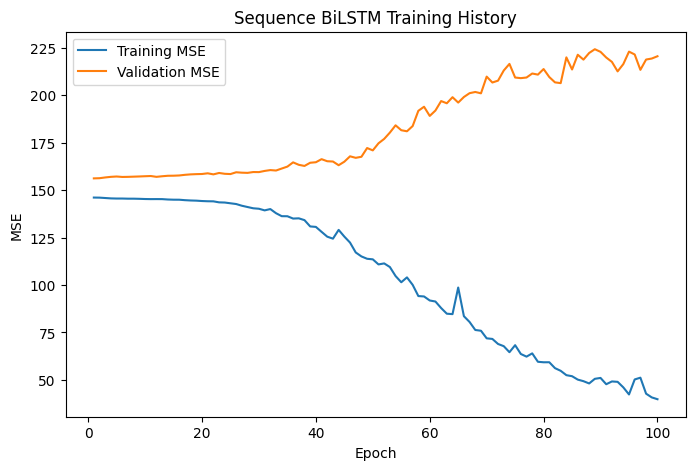

In [24]:
# ---------------------------------------------------------
# CELL 20 — Plot BiLSTM training history
# ---------------------------------------------------------
# Purpose:
#   Visualize training and validation MSE across epochs.
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, BILSTM_EPOCHS + 1),
    bilstm_train_history,
    label="Training MSE"
)

plt.plot(
    range(1, BILSTM_EPOCHS + 1),
    bilstm_validation_history,
    label="Validation MSE"
)

plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.title("Sequence BiLSTM Training History")

plt.legend()

plt.show()

In [25]:
# ---------------------------------------------------------
# CELL 21 — Evaluate the BiLSTM baseline on the test set
# ---------------------------------------------------------
# Purpose:
#   Evaluate the best BiLSTM checkpoint on the held-out
#   test set using exactly the same metrics used for the
#   sequence MLP baseline.
#
# Metrics:
#   - centered-coordinate MSE
#   - coordinate MAE
#   - Kabsch-aligned RMSD
#
# This allows a direct comparison between the two
# sequence-only baselines.
# ---------------------------------------------------------

bilstm_model.eval()

bilstm_test_mse_values = []
bilstm_test_mae_values = []
bilstm_test_kabsch_rmsd_values = []


with torch.no_grad():

    for graph in test_graphs:

        # -------------------------------------------------
        # Create sequence-only input features.
        # -------------------------------------------------

        x = create_baseline_features(
            graph
        )

        # Add batch dimension.
        x = x.unsqueeze(0).to(device)

        # Centered experimental target.
        target = graph.y_centered.to(device)

        # Add batch dimension.
        target_batch = target.unsqueeze(0)

        # -------------------------------------------------
        # Predict coordinates.
        # -------------------------------------------------

        prediction = bilstm_model(
            x
        )

        # Remove batch dimension.
        prediction = prediction.squeeze(0)


        # -------------------------------------------------
        # Direct coordinate metrics.
        # -------------------------------------------------

        mse = torch.mean(
            (prediction - target) ** 2
        ).item()

        mae = torch.mean(
            torch.abs(
                prediction - target
            )
        ).item()

        bilstm_test_mse_values.append(
            mse
        )

        bilstm_test_mae_values.append(
            mae
        )


        # -------------------------------------------------
        # Rotation/translation-invariant RMSD.
        # -------------------------------------------------

        rmsd = kabsch_rmsd(
            prediction.cpu().numpy(),
            target.cpu().numpy()
        )

        bilstm_test_kabsch_rmsd_values.append(
            rmsd
        )


# ---------------------------------------------------------
# Aggregate metrics across the test set.
# ---------------------------------------------------------

bilstm_test_mse = np.mean(
    bilstm_test_mse_values
)

bilstm_test_mae = np.mean(
    bilstm_test_mae_values
)

bilstm_test_kabsch_rmsd = np.mean(
    bilstm_test_kabsch_rmsd_values
)


# ---------------------------------------------------------
# Display final test results.
# ---------------------------------------------------------

print("==============================================")
print("SEQUENCE BiLSTM — TEST RESULTS")
print("==============================================")

print(
    f"Centered-coordinate MSE: "
    f"{bilstm_test_mse:.4f}"
)

print(
    f"Coordinate MAE: "
    f"{bilstm_test_mae:.4f} Å"
)

print(
    f"Kabsch-aligned RMSD: "
    f"{bilstm_test_kabsch_rmsd:.4f} Å"
)

SEQUENCE BiLSTM — TEST RESULTS
Centered-coordinate MSE: 149.6006
Coordinate MAE: 9.2345 Å
Kabsch-aligned RMSD: 19.9618 Å


In [26]:
# ---------------------------------------------------------
# CELL 22 — Compare the sequence-only baselines
# ---------------------------------------------------------
# Purpose:
#   Summarize the final performance of the MLP and BiLSTM
#   baselines using the same held-out test metrics.
# ---------------------------------------------------------

baseline_comparison = pd.DataFrame({
    "Model": [
        "Sequence MLP",
        "Sequence BiLSTM"
    ],

    "Best Validation MSE": [
        best_validation_loss,
        best_bilstm_validation_loss
    ],

    "Test MSE": [
        mean_test_mse,
        bilstm_test_mse
    ],

    "Test MAE (Å)": [
        mean_test_mae,
        bilstm_test_mae
    ],

    "Kabsch RMSD (Å)": [
        mean_test_kabsch_rmsd,
        bilstm_test_kabsch_rmsd
    ]
})

display(
    baseline_comparison.round(4)
)

,Model,Best Validation MSE,Test MSE,Test MAE (Å),Kabsch RMSD (Å)
0,Sequence MLP,156.1834,149.6007,9.2375,19.9726
1,Sequence BiLSTM,156.1882,149.6006,9.2345,19.9618


# Baseline Models — Conclusion

Two sequence-only baselines were evaluated for coarse-grained RNA 3D structure prediction:

1. **Sequence MLP**
2. **Sequence BiLSTM**

Both models used nucleotide identity and normalized sequence position as input and predicted centered experimental C4′ coordinates.

## Test Results

| Model | Test MSE | Test MAE | Kabsch RMSD |
|---|---:|---:|---:|
| Sequence MLP | 149.60 | 9.24 Å | 19.97 Å |
| Sequence BiLSTM | 149.60 | 9.23 Å | 19.96 Å |

The BiLSTM did not provide a meaningful improvement over the simpler MLP. Its training curve showed substantial overfitting, while validation performance did not improve.

## Conclusion

These experiments indicate that sequence-only modeling, even with increased contextual capacity, is insufficient for accurately recovering RNA 3D geometry in this dataset.

This motivates the next stage of the project: introducing an **E(3)-equivariant graph neural network (EGNN)** that can explicitly model relationships between nucleotides and their 3D geometry.

The sequence-only baseline results are retained as the reference point for evaluating the EGNN.